# Data Ingestion

Ingesting the Google Analytics Customer Revenue Prediction competition data
(https://www.kaggle.com/competitions/ga-customer-revenue-prediction), using the
extended `_v2` files (longer time span, needed for quarterly aggregation).

In [1]:
from pathlib import Path

from data.eda import plot_value_counts
from data.kaggle import download_kaggle_competition
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

In [2]:
# Uncomment to (re)download from Kaggle. Requires accepted competition rules + KAGGLE_API_TOKEN.
# Downloaded as zips and kept compressed in data/raw (pandas can read .zip directly).
#download_kaggle_competition("ga-customer-revenue-prediction", DATA_RAW, file_name="train_v2.csv", unzip=False)
#download_kaggle_competition("ga-customer-revenue-prediction", DATA_RAW, file_name="test_v2.csv", unzip=False)

In [3]:
# Skip "hits" (huge nested per-event JSON, not needed) and "customDimensions" to keep this loadable in memory
usecols = [
    "channelGrouping",
    "date",
    "device",
    "fullVisitorId",
    "geoNetwork",
    "socialEngagementType",
    "totals",
    "trafficSource",
    "visitId",
    "visitNumber",
    "visitStartTime",
]
df = pd.read_csv(DATA_RAW / "train_v2.csv.zip", usecols=usecols, dtype={"fullVisitorId": str})
df.head()

,channelGrouping,date,device,fullVisitorId,geoNetwork,socialEngagementType,totals,trafficSource,visitId,visitNumber,visitStartTime
0,Organic Search,20171016,"{""browser"": ""Firefox"", ""browserVersion"": ""not ...",3162355547410993243,"{""continent"": ""Europe"", ""subContinent"": ""Weste...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""1"", ""pageviews"": ""1"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508198450,1,1508198450
1,Referral,20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",8934116514970143966,"{""continent"": ""Americas"", ""subContinent"": ""Nor...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""referralPath"": ""/a/google.com/transportation...",1508176307,6,1508176307
2,Direct,20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",7992466427990357681,"{""continent"": ""Americas"", ""subContinent"": ""Nor...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""(direct)""...",1508201613,1,1508201613
3,Organic Search,20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",9075655783635761930,"{""continent"": ""Asia"", ""subContinent"": ""Western...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508169851,1,1508169851
4,Organic Search,20171016,"{""browser"": ""Chrome"", ""browserVersion"": ""not a...",6960673291025684308,"{""continent"": ""Americas"", ""subContinent"": ""Cen...",Not Socially Engaged,"{""visits"": ""1"", ""hits"": ""2"", ""pageviews"": ""2"",...","{""campaign"": ""(not set)"", ""source"": ""google"", ...",1508190552,1,1508190552


In [4]:
df.shape

(1708337, 11)

In [5]:
df.describe()

,date,visitId,visitNumber,visitStartTime
count,1.708337e+06,1.708337e+06,1.708337e+06,1.708337e+06
mean,2.017016e+07,1.498352e+09,2.335170e+00,1.498352e+09
std,6.485620e+03,1.624937e+07,9.354034e+00,1.624937e+07
min,2.016080e+07,1.470035e+09,1.000000e+00,1.470035e+09
25%,2.016122e+07,1.482738e+09,1.000000e+00,1.482738e+09
50%,2.017071e+07,1.499832e+09,1.000000e+00,1.499832e+09
75%,2.017120e+07,1.512513e+09,1.000000e+00,1.512513e+09
max,2.018043e+07,1.525158e+09,4.570000e+02,1.525158e+09


In [6]:
df.columns

Index(['channelGrouping', 'date', 'device', 'fullVisitorId', 'geoNetwork',
       'socialEngagementType', 'totals', 'trafficSource', 'visitId',
       'visitNumber', 'visitStartTime'],
      dtype='str')

In [7]:
df.dtypes

channelGrouping           str
date                    int64
device                    str
fullVisitorId             str
geoNetwork                str
socialEngagementType      str
totals                    str
trafficSource             str
visitId                 int64
visitNumber             int64
visitStartTime          int64
dtype: object

Notes:

1. `date` needs to be in datetime - for 02_feature_engineering
2. We do not need channelGrouping, customDimensions, socialEngagementType, trafficSource, visitId, visitNumber, visitStartTime 

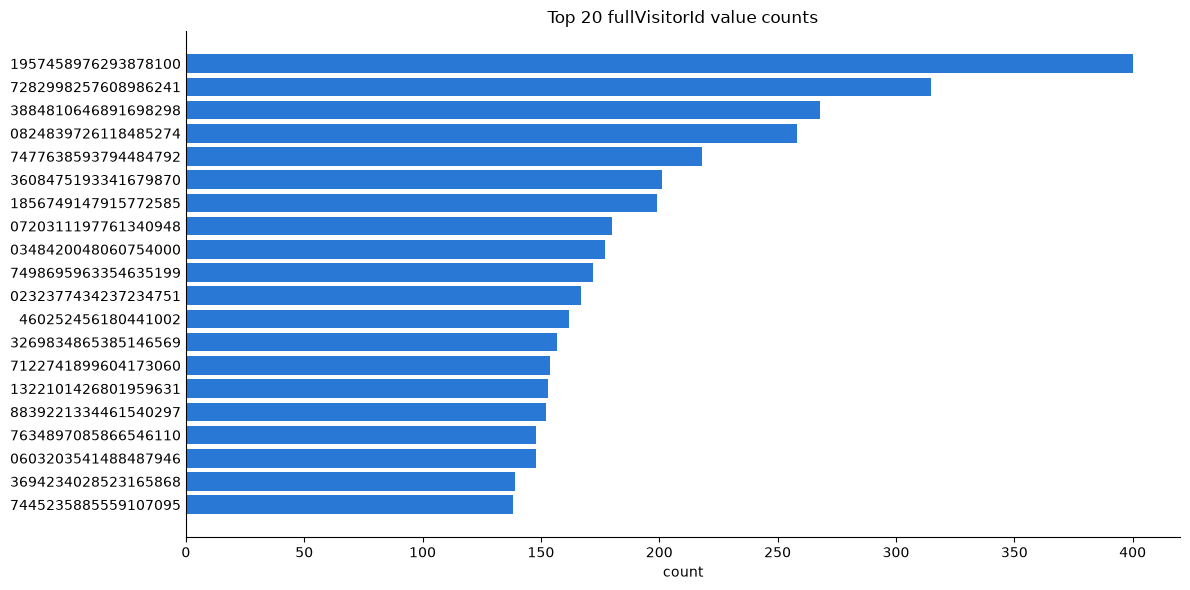

In [8]:
plot_value_counts(df, "fullVisitorId", top_n=20, figsize=(12, 6), title="Top 20 fullVisitorId value counts")

/Users/sajid.ahmed1/Coding/cost_analysis_regression/src/data/eda.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


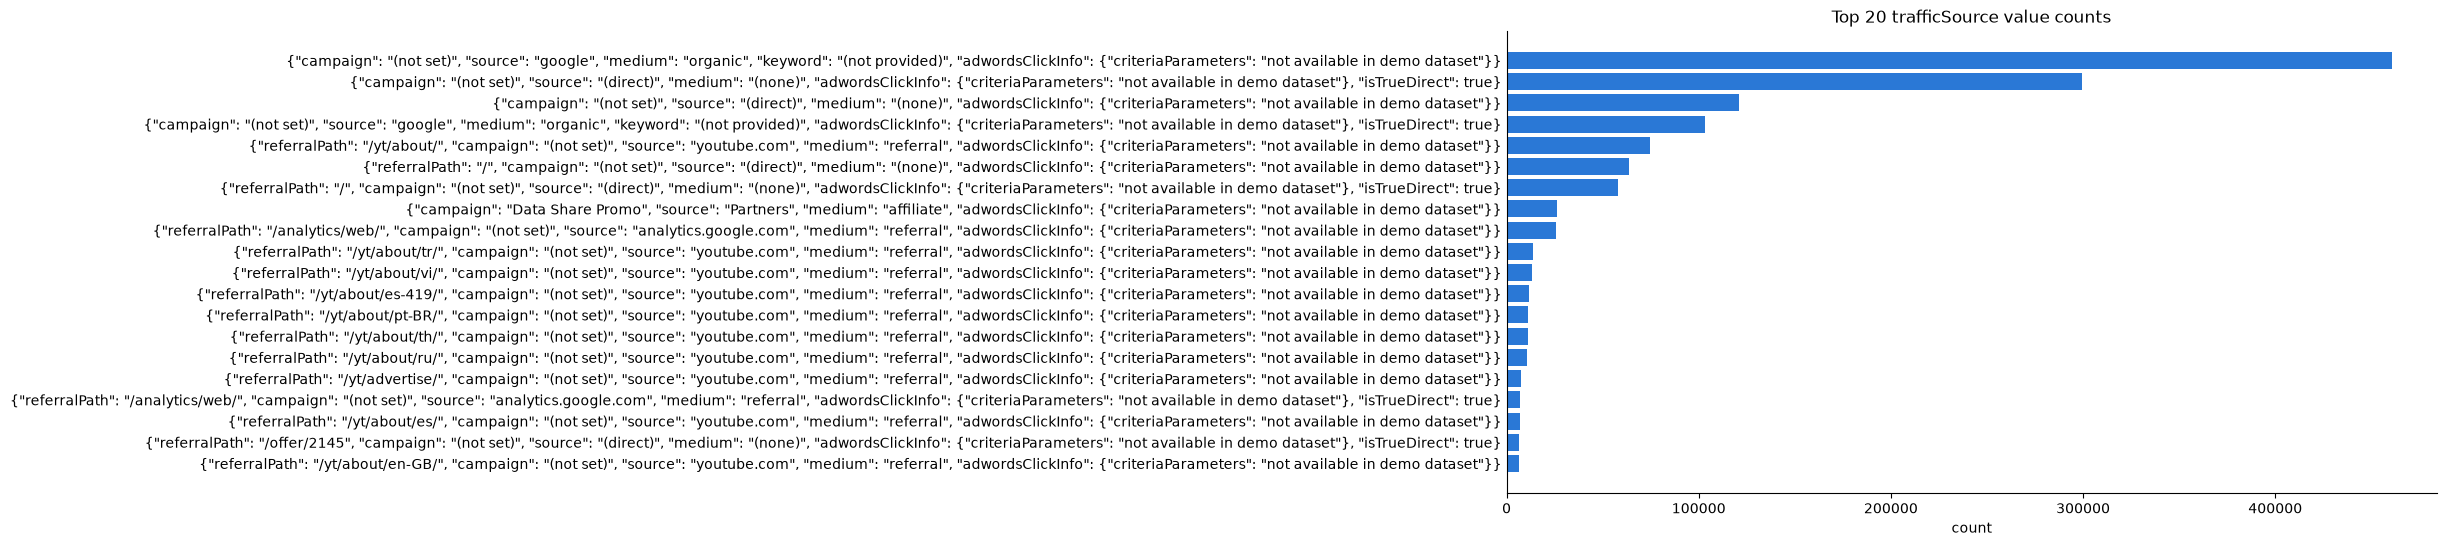

In [9]:
plot_value_counts(df, "trafficSource", top_n=20, figsize=(12, 6), title="Top 20 trafficSource value counts")

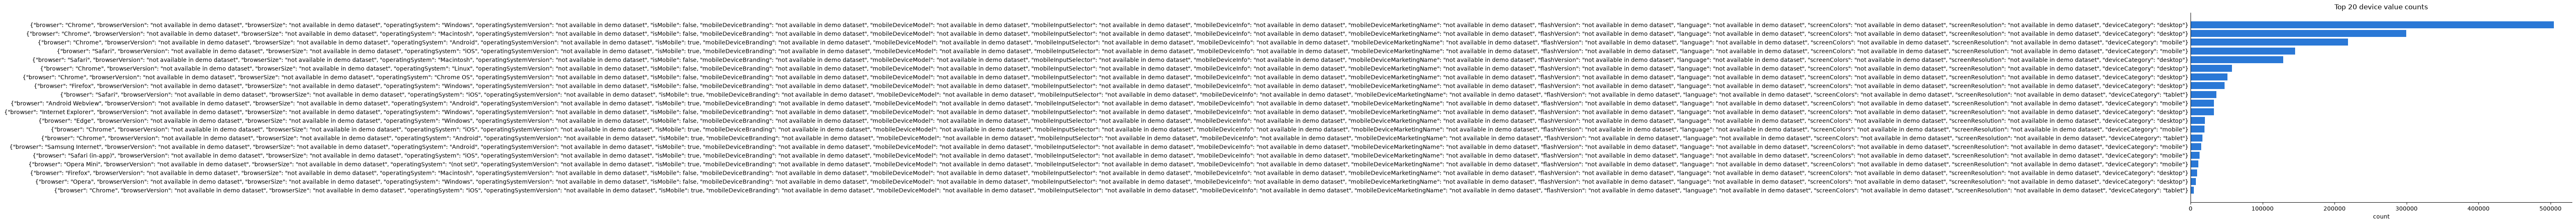

In [10]:
plot_value_counts(df, "device", top_n=20, figsize=(12, 6), title="Top 20 device value counts")